In [1]:
import xarray as xr
import os
import glob
import numpy as np
import warnings
import matplotlib.pyplot as plt
import sys

warnings.filterwarnings("ignore")
sys.path.append('../src')
sys.path.append('../src-double-gyre')
from plot_helpers import create_animation_ffmpeg

%load_ext autoreload
%autoreload 3

# Goal
The purpose of this document is to estimate the noise level in Peta Joules and propose a loss function which combines a few leading PCAs of the noise together with physics-based loss (based on Peta Joules)

Including noise model will allow to prevent shrinking the directions in parameters space aligning with the noise and introduce the early stopping

# 1. Scalar product
First, we need to reconsider the scalar product. Scalar product should not be part of the noise model. Our old scalar product had issues: it had a missing factor of 0.5 in for 2d fields

In [5]:
from helpers.collection_of_experiments import CollectionOfExperiments
ds = CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/filtered', additional_subfolder='output')
ds += CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/bare', additional_subfolder='output')

In [6]:
# Units are petajoules
KE_coarse = ds['R32_R2_FGR3'].KE_joul_series.sel(Time=slice(365*10,None)).compute() * 1e-15
APE_coarse = xr.concat([ds['R32_R2_FGR3'].PE_ssh_series.drop_vars(['zi', 'zl']), ds['R32_R2_FGR3'].PE_joul_series], dim='zi').sel(Time=slice(365*10,None)).compute() * 1e-15

In [8]:
dataset = xr.Dataset()

In [10]:
dataset['KE_mean'] = KE_coarse.mean('Time')
dataset['APE_mean'] = APE_coarse.mean('Time')

dataset['KE_std'] = KE_coarse.std('Time')
dataset['APE_std'] = APE_coarse.std('Time')

In [11]:
# This way of normalization retains MSE-type error but ensures that
# When coarse model has zero energy, the MSE-type error is simply
# the error in PJ
dataset['KE_PJvar'] =  dataset["KE_mean"]
dataset['APE_PJvar'] = dataset["APE_mean"]

# This way of normalization retains MSE-type error but ensures that
# When coarse model has zero energy, the MSE-type error is simply
# the error in PJ
dataset['KE_std_PJvar'] =  dataset["KE_std"]
dataset['APE_std_PJvar'] = dataset["APE_std"]

In [12]:
interfaces = ds['R32_R2_FGR3'].e.sel(Time=slice(365*10,None)).isel(zi=slice(0,2))
u = ds['R32_R2_FGR3'].u.sel(Time=slice(365*10,None))
v = ds['R32_R2_FGR3'].v.sel(Time=slice(365*10,None))
h = ds['R32_R2_FGR3'].h.sel(Time=slice(365*10,None))
param = ds['R32_R2_FGR3'].param
from xgcm import Grid
grid = Grid(param, coords={
        'X': {'center': 'xh', 'outer': 'xq'},
        'Y': {'center': 'yh', 'outer': 'yq'}
        },
        boundary={'X': 'fill', 'Y': 'fill'},
        fill_value = {'Y': 0, 'X': 0})

In [13]:
# This conversion factor includes both reference density and conversion to Petajoules from joules
rho0 = 1035
J_to_PJ = 1e-15
g_prime = xr.DataArray([0.98, 0.0098], dims='zi')
# Elementary volumes and area
dST = param.dxT * param.dyT
# We have to introduce clipping. Otherwise there will be nans in the algorithm.
dVu = param.dxCu * param.dyCu * np.maximum(grid.interp(h, 'X').mean('Time'), 10.0)
dVv = param.dxCv * param.dyCv * np.maximum(grid.interp(h, 'Y').mean('Time'), 10.0)

In [14]:
# Here, factor 0.5 is correcting the definition of energy
# Scalings used to convert the L2 error squared in u and v velocities to units of peta joules
dataset['u_PJvar'] = 1 / (0.5 * J_to_PJ * rho0 * dVu)
dataset['v_PJvar'] = 1 / (0.5 * J_to_PJ * rho0 * dVv)

# Scalings used to convert the L2 error squared in interfaces to units of peta joules
dataset['e_PJvar'] = 1 / (0.5 * J_to_PJ * rho0 * g_prime * dST)

In [15]:
dataset['e_mean'] = interfaces.mean('Time')
dataset['e_std'] = interfaces.std('Time')
dataset['u_mean'] = u.mean('Time')
dataset['v_mean'] = v.mean('Time')
dataset['u_std'] = u.std('Time')
dataset['v_std'] = v.std('Time')

In [16]:
dataset = dataset.transpose('zl',...).transpose('zi',...)
dataset = dataset.compute().fillna(0.)

# 1.1 Test definition of energy functinoal

In [21]:
# Energy norm
print((dataset['KE_mean'] / dataset['KE_PJvar'] * dataset['KE_mean']).values)
# True answer
print((dataset['KE_mean']).values)

[5.44139278 0.34885479]
[5.44139278 0.34885479]


In [22]:
print((dataset['KE_std'] / dataset['KE_std_PJvar'] * dataset['KE_std']).values)
print((dataset['KE_std']).values)

[0.467766   0.07651035]
[0.467766   0.07651035]


In [24]:
print((dataset['APE_mean'] / dataset['APE_PJvar'] * dataset['APE_mean']).values)
print((dataset['APE_mean']).values)

[ 0.7336548  72.61423166]
[ 0.7336548  72.61423166]


In [26]:
print((dataset['APE_std'] / dataset['APE_std_PJvar'] * dataset['APE_std']).values)
print((dataset['APE_std']).values)

[0.0346486  2.72344594]
[0.0346486  2.72344594]


In [34]:
(dataset['u_mean'] / dataset['u_PJvar'] * dataset['u_mean']).sum(['yh', 'xq']) +  \
(dataset['v_mean'] / dataset['v_PJvar'] * dataset['v_mean']).sum(['yq', 'xh'])

<xarray.DataArray (zl: 2)> Size: 16B
array([3.17696466, 0.03077506])
Coordinates:
  * zl       (zl) float64 16B 1.035e+03 1.036e+03

In [42]:
# True values
ds['R32_R2_FGR3'].MKE_joul.values * 1e-15

array([3.17698126, 0.03080464])

In [44]:
(dataset['u_std'] / dataset['u_PJvar'] * dataset['u_std']).sum(['yh', 'xq']) + \
(dataset['v_std'] / dataset['v_PJvar'] * dataset['v_std']).sum(['yq', 'xh'])

<xarray.DataArray (zl: 2)> Size: 16B
array([2.25311005, 0.31857944])
Coordinates:
  * zl       (zl) float64 16B 1.035e+03 1.036e+03

In [45]:
# True values
ds['R32_R2_FGR3'].EKE_joul.values * 1e-15

array([2.26441152, 0.31805015])

In [46]:
(dataset['e_mean'] / dataset['e_PJvar'] * dataset['e_mean']).sum(['yh', 'xh'])

<xarray.DataArray (zi: 2)> Size: 16B
array([6.79599541e-01, 1.59300420e+04])
Coordinates:
  * zi       (zi) float64 16B 1.034e+03 1.036e+03

In [51]:
# True values
print(ds['R32_R2_FGR3'].MPE_ssh.values * 1e-15)
# This value is different because of lack of reference profile in l2-norm
print(ds['R32_R2_FGR3'].MPE_joul.values * 1e-15)

0.6795995413260847
68.73658660691332


In [52]:
(dataset['e_std'] / dataset['e_PJvar'] * dataset['e_std']).sum(['yh', 'xh'])

<xarray.DataArray (zi: 2)> Size: 16B
array([0.05405526, 3.8776527 ])
Coordinates:
  * zi       (zi) float64 16B 1.034e+03 1.036e+03

In [54]:
# True values
print(ds['R32_R2_FGR3'].EPE_ssh.values * 1e-15)
# True values
print(ds['R32_R2_FGR3'].EPE_joul.values * 1e-15)

0.05405526127276038
3.8776450520303762


In [63]:
# Energy decomposition and integral values are similar
print((ds['R32_R2_FGR3'].EPE_ssh + ds['R32_R2_FGR3'].MPE_ssh).values*1e-15)
print((ds['R32_R2_FGR3'].EPE_joul + ds['R32_R2_FGR3'].MPE_joul).values*1e-15)
print((dataset['APE_mean']).values)

0.7336548025988451
72.61423165894371
[ 0.7336548  72.61423166]


In [64]:
dataset.to_netcdf('../scripts/R32/R2_FGR3_PJ_0.5_corrected.nc')

In [83]:
del dataset

# 2. Evaluating leading eigenvalue of the variability noise in petajoules

In [2]:
noise_model = xr.open_dataset('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/noise_model/metrics_00.nc').isel(iter=0).load()

In [88]:
observation_netcdf = xr.open_dataset('../scripts/R32/R2_FGR3_PJ_0.5_corrected.nc').load()

In [8]:
observational_vector = ["e_mean", "e_std", "u_mean", "u_std", "v_mean", "v_std", "KE_mean", "KE_std", "APE_mean", "APE_std"]
gamma_vector = ["e_PJvar", "e_PJvar", "u_PJvar", "u_PJvar", "v_PJvar", "v_PJvar", "KE_PJvar", "KE_std_PJvar", "APE_PJvar", "APE_std_PJvar"]
#observational_vector = ["e_mean", "e_std", "KE_mean", "KE_std", "APE_mean", "APE_std"]
#gamma_vector = ["e_PJvar", "e_PJvar", "KE_PJvar", "KE_std_PJvar", "APE_PJvar", "APE_std_PJvar"]

len_obs = np.sum([observation_netcdf[metric].size for metric in observational_vector])
ens_size = len(noise_model.ens)

# Create forward model evaluation matrix
g_ens = np.full(
    (len_obs, ens_size),
    np.nan,
    dtype="float64"
)

# We create observational matrix in normalized space where usual L2-norm returns answer in PetaJoules
for ens_member in range(ens_size):
    g_ens[:,ens_member] = np.concatenate([
        noise_model[metric].isel(ens=ens_member).values.ravel() / np.sqrt(observation_netcdf[gamma].values.ravel()) 
        for metric, gamma in zip(observational_vector, gamma_vector)])

In [9]:
g_ens.shape

(21464, 1000)

In [10]:
# Find fluctuations
g_ens = g_ens - g_ens.mean(1,keepdims=True)

In [11]:
# So typical noise magnitude is just 0.4 Peta Joules
(g_ens**2).sum(0).mean()

0.4243932624823474

In [711]:
# Evaluating the mean model error
y_error = np.concatenate([
            (noise_model[metric].mean('ens').values.ravel() - observation_netcdf[metric].values.ravel()) / np.sqrt(observation_netcdf[gamma].values.ravel()) 
            for metric, gamma in zip(observational_vector, gamma_vector)])


In [712]:
# Model error is clearly much bigger than the noise and equals to 10 Peta Joules
# However we note that the model error should be high presumably because there is structural error
# So we better compare the typical ensemble spread with the noise level
(y_error**2).sum(0)

10.039545204425346

# 2.1 Analyzing leading PCA components of the variability noise

In [713]:
g_ens.shape

(21464, 1000)

In [714]:
# g_ens: shape (21464, 1000)
U, s, Vt = np.linalg.svd(g_ens, full_matrices=False)

# leading eigenvalues of g_ens @ g_ens.T / ens_size
eigvals = s**2 / ens_size

In [715]:
# So the sum of eigenvalues is clearly the second norm of random perturbations
# Also note that sum of eigenvalues is the trace of the covariance matrix
eigvals.sum()

0.42439326248234804

In [716]:
eigvals[0:10].sum()

0.35616585363944747

In [502]:
percent_of_variance = np.cumsum(eigvals) / np.sum(eigvals) * 100

Text(0.5, 1.0, 'Observational noise PCA structure')

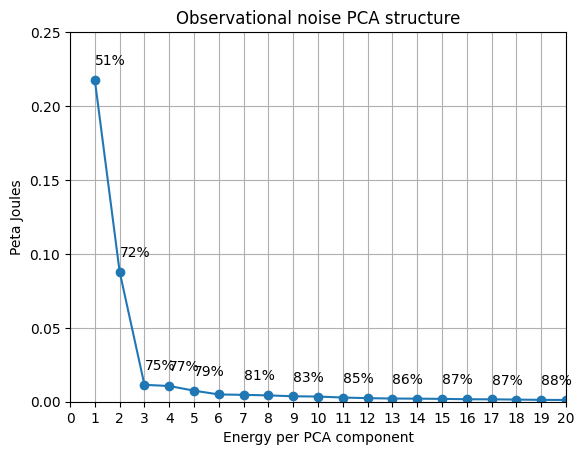

In [527]:
plt.plot(np.arange(1,21),eigvals[:20], marker='o')
for i in [0,1,2,3,4,6,8,10,12,14,16,18]:
    plt.text(i+1, eigvals[i]+0.01, f"{percent_of_variance[i]:.0f}%")
plt.ylim([0,0.25])
plt.xlim([0,20])
plt.ylabel('Peta Joules')
plt.xlabel('Energy per PCA component')
plt.xticks(np.arange(21));
plt.grid()
plt.title('Observational noise PCA structure')

Text(0.5, 1.0, 'Observational noise PCA structure')

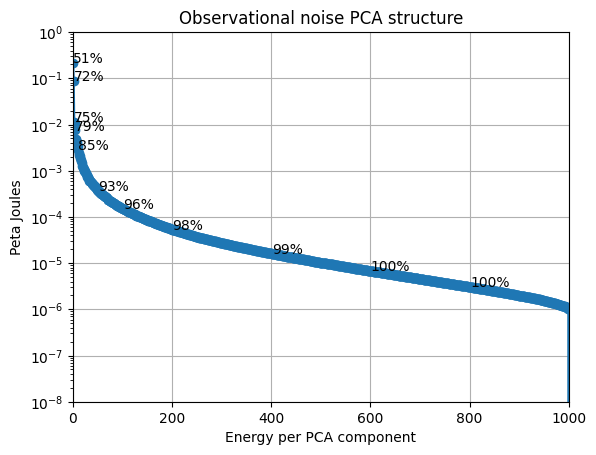

In [620]:
plt.plot(np.arange(1,1001),eigvals[:1000], marker='o')
for i in [0, 1, 2, 4, 10, 50, 100, 200, 400, 600, 800]:
    plt.text(i+1, eigvals[i], f"{percent_of_variance[i]:.0f}%")
plt.ylim([1e-8,1e0])
plt.xlim([0,1000])
plt.ylabel('Peta Joules')
plt.xlabel('Energy per PCA component')
#plt.xticks(np.arange(21));
plt.grid()
plt.yscale('log')
plt.title('Observational noise PCA structure')

# How many PCAs we need to keep to do not inflate trace too much?
A reference number by Dunbar (2020). Inflated noise covariance matrix trace is 4 times bigger.

In [615]:
# The simplest approach where we retain full PCA spectrum and add uniform background noise
(0.00006 * len_obs + eigvals.sum()) / eigvals.sum()

4.034543933301877

In [627]:
0.00006 * len_obs

1.28784

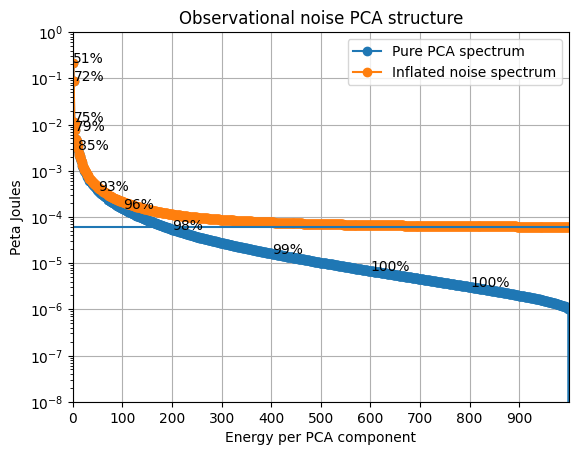

In [623]:
plt.plot(np.arange(1,1001),eigvals[:1000], marker='o', label='Pure PCA spectrum')
plt.plot(np.arange(1,1001),eigvals[:1000]+0.00006, marker='o', label='Inflated noise spectrum')
plt.axhline(y=0.00006)
for i in [0, 1, 2, 4, 10, 50, 100, 200, 400, 600, 800]:
    plt.text(i+1, eigvals[i], f"{percent_of_variance[i]:.0f}%")
plt.ylim([1e-8,1e0])
plt.xlim([0,1000])
plt.ylabel('Peta Joules')
plt.xlabel('Energy per PCA component')
plt.xticks(np.arange(0,1000,100));
plt.grid()
plt.yscale('log')
plt.title('Observational noise PCA structure')
plt.legend()

# We can argue that we do not want to inflate the noise covariance matrix much and consider only inflating it twice.
This decomposition requires even more PCAs to retain: 300-400. It is too much.

In [632]:
# The simplest approach where we retain full PCA spectrum and add uniform background noise
(0.00002 * len_obs + eigvals.sum()) / eigvals.sum()

2.0115146444339587

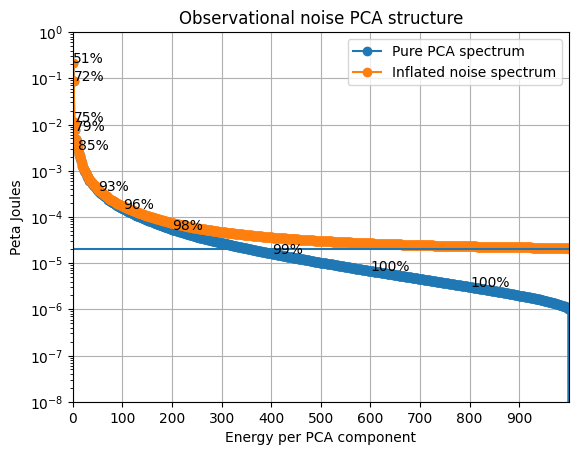

In [633]:
plt.plot(np.arange(1,1001),eigvals[:1000], marker='o', label='Pure PCA spectrum')
plt.plot(np.arange(1,1001),eigvals[:1000]+0.00002, marker='o', label='Inflated noise spectrum')
plt.axhline(y=0.00002)
for i in [0, 1, 2, 4, 10, 50, 100, 200, 400, 600, 800]:
    plt.text(i+1, eigvals[i], f"{percent_of_variance[i]:.0f}%")
plt.ylim([1e-8,1e0])
plt.xlim([0,1000])
plt.ylabel('Peta Joules')
plt.xlabel('Energy per PCA component')
plt.xticks(np.arange(0,1000,100));
plt.grid()
plt.yscale('log')
plt.title('Observational noise PCA structure')
plt.legend()

# Keep the required PCAs components to a hundred

In [634]:
# The simplest approach where we retain full PCA spectrum and add uniform background noise
(1e-4 * len_obs + eigvals.sum()) / eigvals.sum()

6.057573222169794

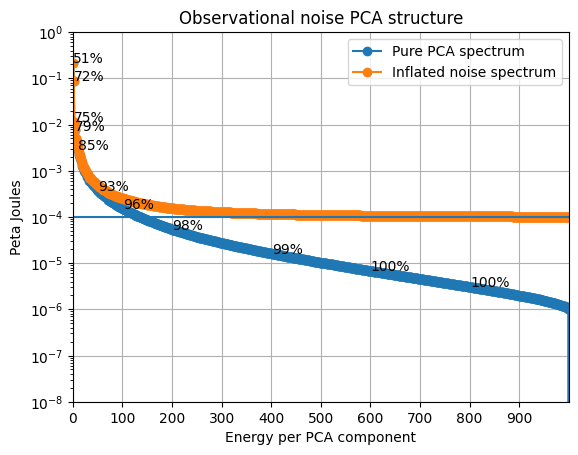

In [635]:
plt.plot(np.arange(1,1001),eigvals[:1000], marker='o', label='Pure PCA spectrum')
plt.plot(np.arange(1,1001),eigvals[:1000]+1e-4, marker='o', label='Inflated noise spectrum')
plt.axhline(y=1e-4)
for i in [0, 1, 2, 4, 10, 50, 100, 200, 400, 600, 800]:
    plt.text(i+1, eigvals[i], f"{percent_of_variance[i]:.0f}%")
plt.ylim([1e-8,1e0])
plt.xlim([0,1000])
plt.ylabel('Peta Joules')
plt.xlabel('Energy per PCA component')
plt.xticks(np.arange(0,1000,100));
plt.grid()
plt.yscale('log')
plt.title('Observational noise PCA structure')
plt.legend()

# Simplest option. We should treat the number of PCAs to be retained as the hyperparameter.
Then we replace the regularization with the smallest PCA component

Probably inflation is so big because our PCA analysis samples only 1000 direction in very high-dimensional space (22000)

In [640]:
num_pcas=10
print('Variance inflation factor', (eigvals[num_pcas-1] * len_obs + eigvals[:num_pcas].sum()) / eigvals.sum())
print('Noise model in Peta Joules', (eigvals[num_pcas-1] * len_obs + eigvals[:num_pcas].sum()))

Variance inflation factor 177.6198764524563
Noise model in Peta Joules 75.38067884936952


In [642]:
num_pcas=100
print('Variance inflation factor', (eigvals[num_pcas-1] * len_obs + eigvals[:num_pcas].sum()) / eigvals.sum())
print('Noise model in Peta Joules', (eigvals[num_pcas-1] * len_obs + eigvals[:num_pcas].sum()))

Variance inflation factor 8.717408338637425
Noise model in Peta Joules 3.699609365225162


In [648]:
num_pcas=200
print('Variance inflation factor', (eigvals[num_pcas-1] * len_obs + eigvals[:num_pcas].sum()) / eigvals.sum())
print('Noise model in Peta Joules', (eigvals[num_pcas-1] * len_obs + eigvals[:num_pcas].sum()))

Variance inflation factor 3.7265841453725406
Noise model in Peta Joules 1.5815372033696453


# Suggestion

I expect that training dynamics might be very different with different number of PCAs:
* Retaining many PCAs will result in complete neglection of domain-averaged energetics
* Keeping a small number of PCAs will result in more accurate fitting of domain-averaged metrics by in very early stopping (probably in 1 iteration)

# Determine the number of PCAs based on the convergence properties of the spectrum! Answer: PCA spectrum converges pretty well with any number of simulations.

In [670]:
# g_ens: shape (21464, 1000)
ens_size = 500
idx = np.random.choice(np.arange(1000), ens_size, replace=False)
U, s, Vt = np.linalg.svd(g_ens[:,idx], full_matrices=False)

# leading eigenvalues of g_ens @ g_ens.T / ens_size
eigvals_500 = s**2 / ens_size

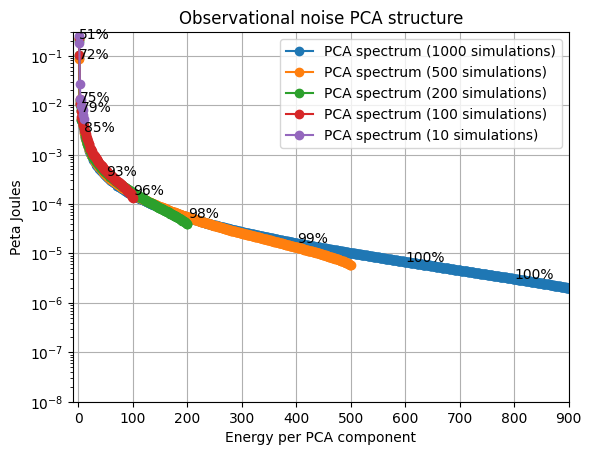

In [694]:
plt.plot(np.arange(1,1001),eigvals[:1000], marker='o', label='PCA spectrum (1000 simulations)')
plt.plot(np.arange(1,501),eigvals_500[:500], marker='o', label='PCA spectrum (500 simulations)')
plt.plot(np.arange(1,201),eigvals_200[:200], marker='o', label='PCA spectrum (200 simulations)')
plt.plot(np.arange(1,101),eigvals_100[:100], marker='o', label='PCA spectrum (100 simulations)')
plt.plot(np.arange(1,11),eigvals_10[:10], marker='o', label='PCA spectrum (10 simulations)')
for i in [0, 1, 2, 4, 10, 50, 100, 200, 400, 600, 800]:
    plt.text(i+1, eigvals[i], f"{percent_of_variance[i]:.0f}%")
plt.ylim([1e-8,0.3])
plt.xlim([-10,100])
plt.ylabel('Peta Joules')
plt.xlabel('Energy per PCA component')
plt.xticks(np.arange(0,1000,100));
plt.grid()
plt.yscale('log')
plt.title('Observational noise PCA structure')
plt.legend()

# Decomposition of the model error in the error covariance space

In [722]:
y_error_PCAs = U.T@y_error

In [721]:
np.linalg.norm(y_error)**2

10.039545204425345

In [ ]:
# Most of the model error
np.linalg.norm(y_error_PCAs)**2

8.804581650781072

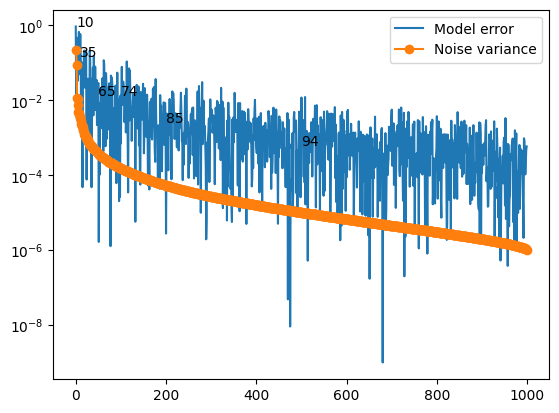

In [737]:
plt.semilogy(y_error_PCAs**2, label='Model error')
plt.plot(np.arange(1,1000),eigvals[:999], marker='o', label='Noise variance')
percentage = np.cumsum(y_error_PCAs**2) / np.sum(y_error_PCAs**2) * 100
for j in [1,10,50,100,200,500]:
    plt.text(j, y_error_PCAs[j-1]**2, int(percentage[j-1]));

plt.legend()

# Whitening of the model error

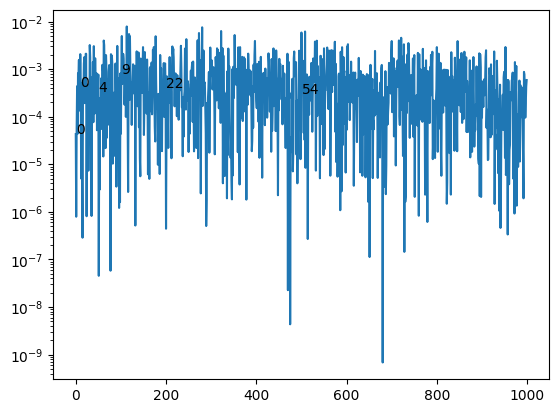

In [746]:
background_noise_level=1e-5
fltr = background_noise_level/(eigvals + background_noise_level)

plt.semilogy(fltr * y_error_PCAs**2)
percentage = np.cumsum(fltr * y_error_PCAs**2) / np.sum(fltr * y_error_PCAs**2) * 100
for j in [1,10,50,100,200,500]:
    plt.text(j, fltr[j-1] * y_error_PCAs[j-1]**2, int(percentage[j-1]));

In [747]:
background_noise_level * len_obs

0.21464000000000003

# Structure of leading PCA vectors

1.0000000000000044
0.9378096780141


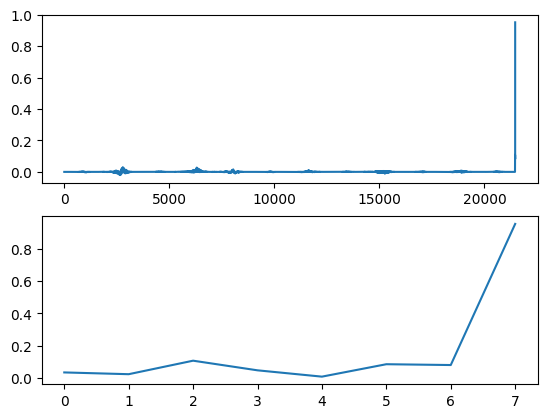

In [584]:
# Leading PCA clearly suggests prevalent role of domain-averaged metrics, especially APE_std
plt.subplot(2,1,1)
plt.plot(U[:,0])
plt.subplot(2,1,2)
plt.plot(U[-8:,0])
print((U[:,0]**2).sum())
print((U[-8:,0]**2).sum())

1.0000000000000004
0.3118678817993357


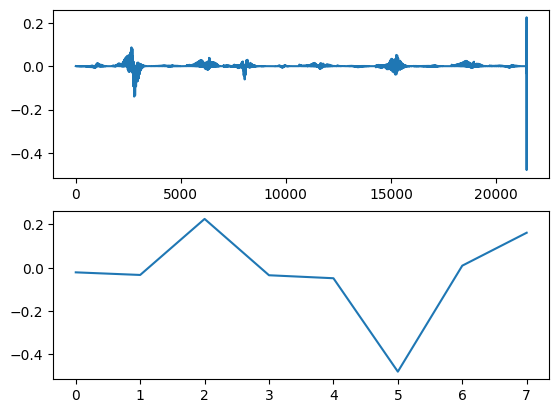

In [587]:
# Second PCA suggest the role of internal interface APE mean and KE_std for the upper layer. However, this one already more dominant by 2D fields
plt.subplot(2,1,1)
plt.plot(U[:,1])
plt.subplot(2,1,2)
plt.plot(U[-8:,1])
print((U[:,1]**2).sum())
print((U[-8:,1]**2).sum())

1.0000000000000018
0.6666991256942709


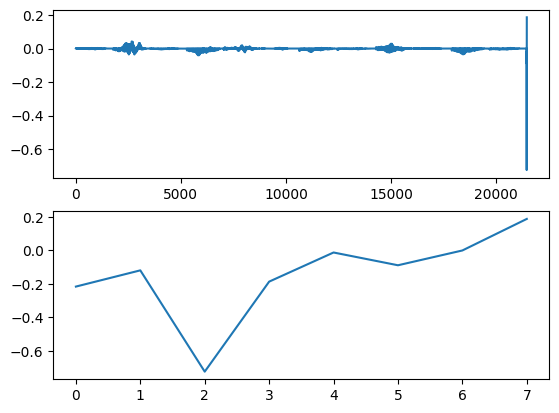

In [ ]:
# Third PCA
plt.subplot(2,1,1)
plt.plot(U[:,2])
plt.subplot(2,1,2)
plt.plot(U[-8:,2])

print((U[:,2]**2).sum())
print((U[-8:,2]**2).sum())

1.0000000000000016
0.02267350191514292


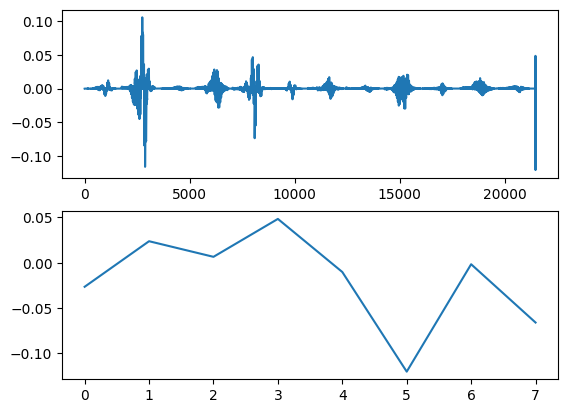

In [590]:
# Forth PCA is purely related to 2d fields
plt.subplot(2,1,1)
plt.plot(U[:,3])
plt.subplot(2,1,2)
plt.plot(U[-8:,3])

print((U[:,3]**2).sum())
print((U[-8:,3]**2).sum())

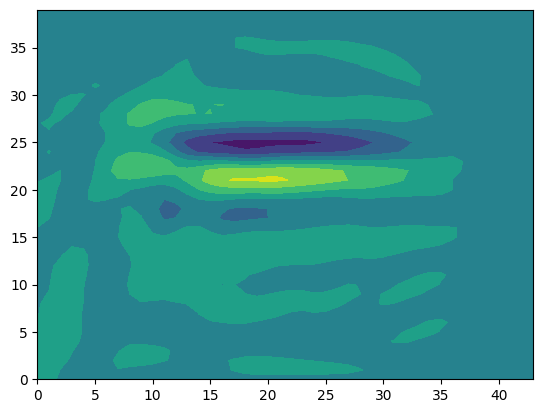

In [702]:
plt.contourf(U[:40*44,3].reshape(40,44))

# 3. Ensemble spread at the last iteration is on the order of noise level!
Note: we have to skip u,v metrics as they are not precomputed
Note: Priors do not seem to considerably increase the spread of the initial ensemble in joules

Initial ensemble spread: ~15 Peta Joules
Initial model error: 15 Peta Joules
Ensemble spread after few iteration: 0.5-1.0 Peta Joules

In [452]:
metrics = xr.open_mfdataset('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_series_PJ_all_prior_cond_100/metrics*.nc').isel(iter=4).load()

In [453]:
observational_vector = ["e_mean", "e_std", "u_mean", "u_std", "v_mean", "v_std", "KE_mean", "KE_std", "APE_mean", "APE_std"]
gamma_vector = ["e_PJvar", "e_PJvar", "u_PJvar", "u_PJvar", "v_PJvar", "v_PJvar", "KE_PJvar", "KE_std_PJvar", "APE_PJvar", "APE_std_PJvar"]

len_obs = np.sum([observation_netcdf[metric].size for metric in observational_vector])
ens_size = len(metrics.ens)

# Create forward model evaluation matrix
g_ens = np.full(
    (len_obs, ens_size),
    np.nan,
    dtype="float64"
)

# We create observational matrix in normalized space where usual L2-norm returns answer in PetaJoules
for ens_member in range(ens_size):
    for metric, gamma in zip(observational_vector, gamma_vector):
        g_ens[:,ens_member] = np.concatenate([
            metrics[metric].isel(ens=ens_member).values.ravel() / np.sqrt(observation_netcdf[gamma].values.ravel()) 
            for metric, gamma in zip(observational_vector, gamma_vector)])

In [454]:
g_ens.shape

(21464, 200)

In [455]:
# Find fluctuations
g_ens = g_ens - np.nanmean(g_ens, 1,keepdims=True)

In [456]:
# Ensemble spread in Peta Joules is comparable to the noise (0.37 Peta Joules). If will additionally include Tikhonov regularization to the noise model, this will definitely be at the noise level.
gsum = (g_ens**2).sum(0)
gsum[gsum<100].mean()

1.0484629334553077

In [457]:
# Model error at this iteration
# Evaluating the mean model error
y_true = np.concatenate([
            (metrics[metric].mean('ens').values.ravel() - observation_netcdf[metric].values.ravel()) / np.sqrt(observation_netcdf[gamma].values.ravel()) 
            for metric, gamma in zip(observational_vector, gamma_vector)])
(y_true**2).sum(0)

17.33863562321769

# Calibration using noise models

In [276]:
def plot_params(exp='R2_FGR3_series', color='tab:blue'):
    metrics = xr.open_mfdataset(f'/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/{exp}/metrics*.nc')
    for pdim in range(13):
        plt.subplot(3,5,pdim+1)
        mean = metrics.param.mean('ens').isel(pdim=pdim)
        vmin = metrics.param.min('ens').isel(pdim=pdim)
        vmax = metrics.param.max('ens').isel(pdim=pdim)
        x = mean[mean.dims[0]]
        plt.plot(x, mean, color=color, label=exp)
        plt.fill_between(x, vmin, vmax, alpha=0.3, color=color)
        plt.title(pdim)
        plt.xlabel('')
        plt.ylabel('')

        plt.xticks(np.arange(10))
        plt.xlim([0,9])

    plt.legend(bbox_to_anchor=(1,1))
    #plt.tight_layout()

In [288]:
plt.figure(figsize=(16,6))
observation = xr.open_dataset('/home/pp2681/calibration/scripts/R32/R2_FGR3_series_loss.nc').astype('float64')
def plot_metrics(exp='R2_FGR3_series_200', color='tab:blue'):
    metrics = xr.open_mfdataset(f'/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/{exp}/metrics*.nc')
    try:
        metrics['e_mean_RMSE'] = metrics['RMSE_e_mean']
        metrics['e_std_RMSE'] = metrics['RMSE_e_std']
    except:
        pass
    
    plt.subplot(2,6,1)
    metrics.KE_mean.isel(zl=0).mean('ens').plot(marker='o', color=color)
    plt.axhline(y=observation.KE_mean.isel(zl=0), color='k', ls='--')
    plt.ylim([0,None])
    plt.xticks(np.arange(10))
    plt.grid()
    plt.xlabel('Iteration')
    plt.title('KE mean [J]')
    plt.ylabel('Upper layer')
    plt.ylim([0,7])


    plt.subplot(2,6,2)
    metrics.KE_std.isel(zl=0).mean('ens').plot(marker='o', color=color)
    plt.axhline(y=observation.KE_std.isel(zl=0), color='k', ls='--')
    plt.title('')
    plt.ylim([0,None])
    plt.xticks(np.arange(10))
    plt.grid()
    plt.xlabel('Iteration')
    plt.title('KE STD [J]')
    plt.ylabel('')
    plt.ylim([0,1.2])

    plt.subplot(2,6,3)
    metrics.APE_mean.isel(zi=0).mean('ens').plot(marker='o', color=color)
    plt.axhline(y=observation.APE_mean.isel(zi=0), color='k', ls='--')
    plt.title('')
    plt.ylim([0,None])
    plt.xticks(np.arange(10))
    plt.grid()
    plt.xlabel('Iteration')
    plt.title('APE MEAN [J]')
    plt.ylabel('')

    plt.subplot(2,6,4)
    metrics.APE_std.isel(zi=0).mean('ens').plot(marker='o', color=color)
    plt.axhline(y=observation.APE_std.isel(zi=0), color='k', ls='--')
    plt.title('')
    plt.ylim([0,None])
    plt.xticks(np.arange(10))
    plt.grid()
    plt.xlabel('Iteration')
    plt.title('APE STD [J]')
    plt.ylabel('')
    plt.ylim([0,0.065])

    plt.subplot(2,6,5)
    metrics.e_mean_RMSE_MAP.isel(zi=0).plot(marker='o', color=color)
    plt.title('')
    plt.ylim([0,0.25])
    plt.xticks(np.arange(10))
    plt.grid()
    plt.xlabel('Iteration')
    plt.title('RMSE SSH MEAN [m]')
    plt.ylabel('')

    plt.subplot(2,6,6)
    metrics.e_std_RMSE_MAP.isel(zi=0).plot(marker='o', color=color)
    plt.title('')
    plt.ylim([0,0.15])
    plt.xticks(np.arange(10))
    plt.grid()
    plt.xlabel('Iteration')
    plt.title('RMSE SSH STD [m]')
    plt.ylabel('')

    plt.subplot(2,6,7)
    metrics.KE_mean.isel(zl=1).mean('ens').plot(marker='o', color=color)
    plt.axhline(y=observation.KE_mean.isel(zl=1), color='k', ls='--')
    plt.ylim([0,None])
    plt.xticks(np.arange(10))
    plt.grid()
    plt.xlabel('Iteration')
    plt.title('KE mean [J]')
    plt.ylabel('Lower layer')
    plt.ylim([0,0.5])


    plt.subplot(2,6,8)
    metrics.KE_std.isel(zl=1).mean('ens').plot(marker='o', color=color)
    plt.axhline(y=observation.KE_std.isel(zl=1), color='k', ls='--')
    plt.title('')
    plt.ylim([0,None])
    plt.xticks(np.arange(10))
    plt.grid()
    plt.xlabel('Iteration')
    plt.title('KE STD [J]')
    plt.ylabel('')
    plt.ylim([0,0.5])

    plt.subplot(2,6,9)
    metrics.APE_mean.isel(zi=1).mean('ens').plot(marker='o', color=color)
    plt.axhline(y=observation.APE_mean.isel(zi=1), color='k', ls='--')
    plt.title('')
    plt.ylim([0,None])
    plt.xticks(np.arange(10))
    plt.grid()
    plt.xlabel('Iteration')
    plt.title('APE MEAN [J]')
    plt.ylabel('')

    plt.subplot(2,6,10)
    metrics.APE_std.isel(zi=1).mean('ens').plot(marker='o', color=color)
    plt.axhline(y=observation.APE_std.isel(zi=1), color='k', ls='--')
    plt.title('')
    plt.ylim([0,None])
    plt.xticks(np.arange(10))
    plt.grid()
    plt.xlabel('Iteration')
    plt.title('APE STD [J]')
    plt.ylabel('')

    plt.subplot(2,6,11)
    metrics.e_mean_RMSE_MAP.isel(zi=1).plot(marker='o', color=color)
    plt.title('')
    plt.ylim([0,25])
    plt.xticks(np.arange(10))
    plt.grid()
    plt.xlabel('Iteration')
    plt.title('RMSE SSH MEAN [m]')
    plt.ylabel('')

    plt.subplot(2,6,12)
    metrics.e_std_RMSE_MAP.isel(zi=1).plot(marker='o', color=color)
    plt.title('')
    plt.ylim([0,15])
    plt.xticks(np.arange(10))
    plt.grid()
    plt.xlabel('Iteration')
    plt.title('RMSE SSH STD [m]')
    plt.ylabel('')

    plt.tight_layout()

<Figure size 1600x600 with 0 Axes>

In [ ]:
plt.figure(figsize=(12,8))
for pdim in range(13):
    plt.subplot(3,5,pdim+1)
    metrics.param.mean('ens').isel(pdim=pdim).plot()
    metrics.param.min('ens').isel(pdim=pdim).plot()
    metrics.param.max('ens').isel(pdim=pdim).plot()
    plt.title(pdim)

plt.tight_layout()

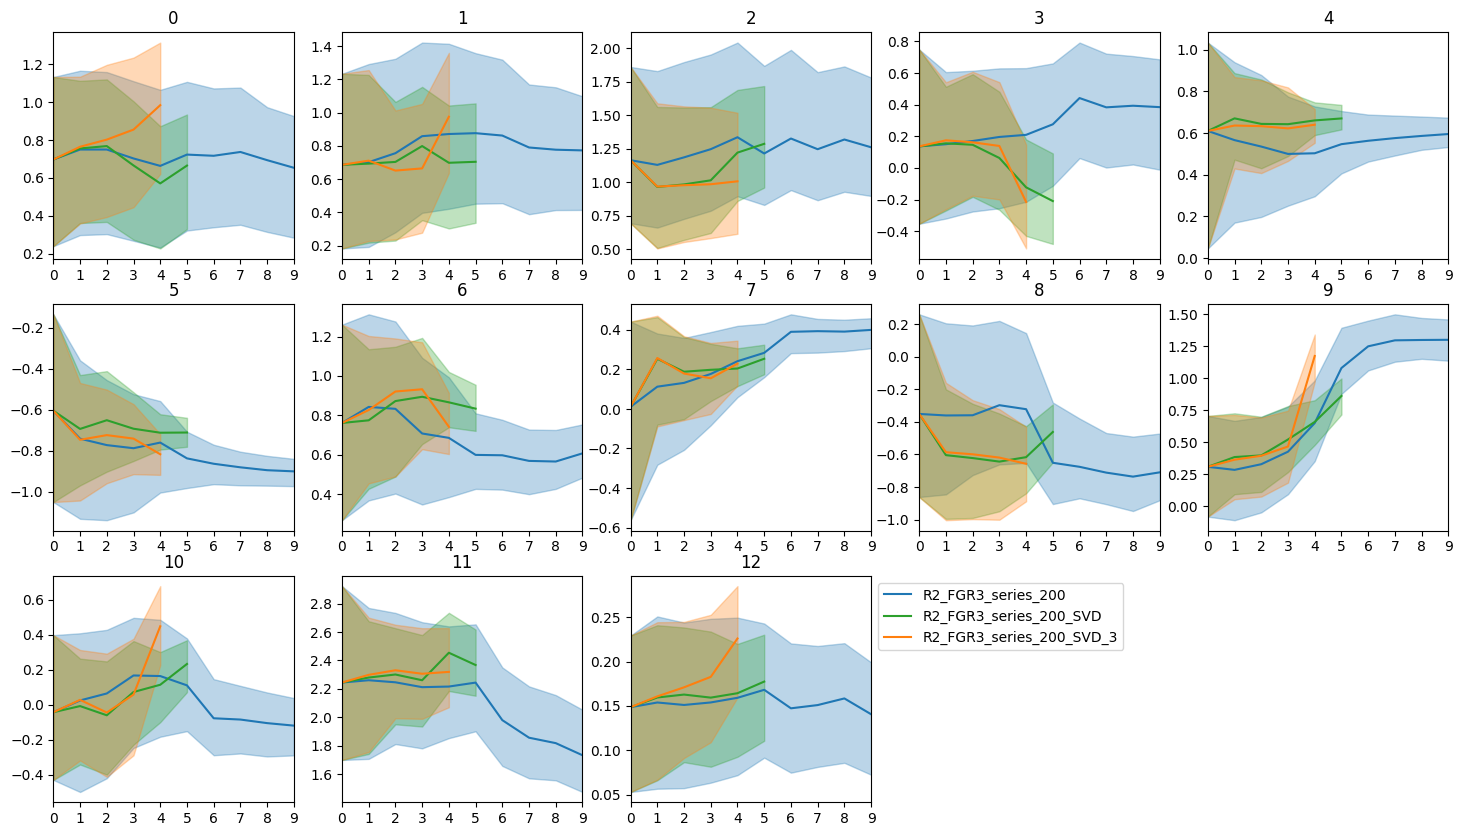

In [33]:
plt.figure(figsize=(18,10))
plot_params('R2_FGR3_series_200')
plot_params('R2_FGR3_series_200_SVD', color='tab:green')
plot_params('R2_FGR3_series_200_SVD_3', color='tab:orange')

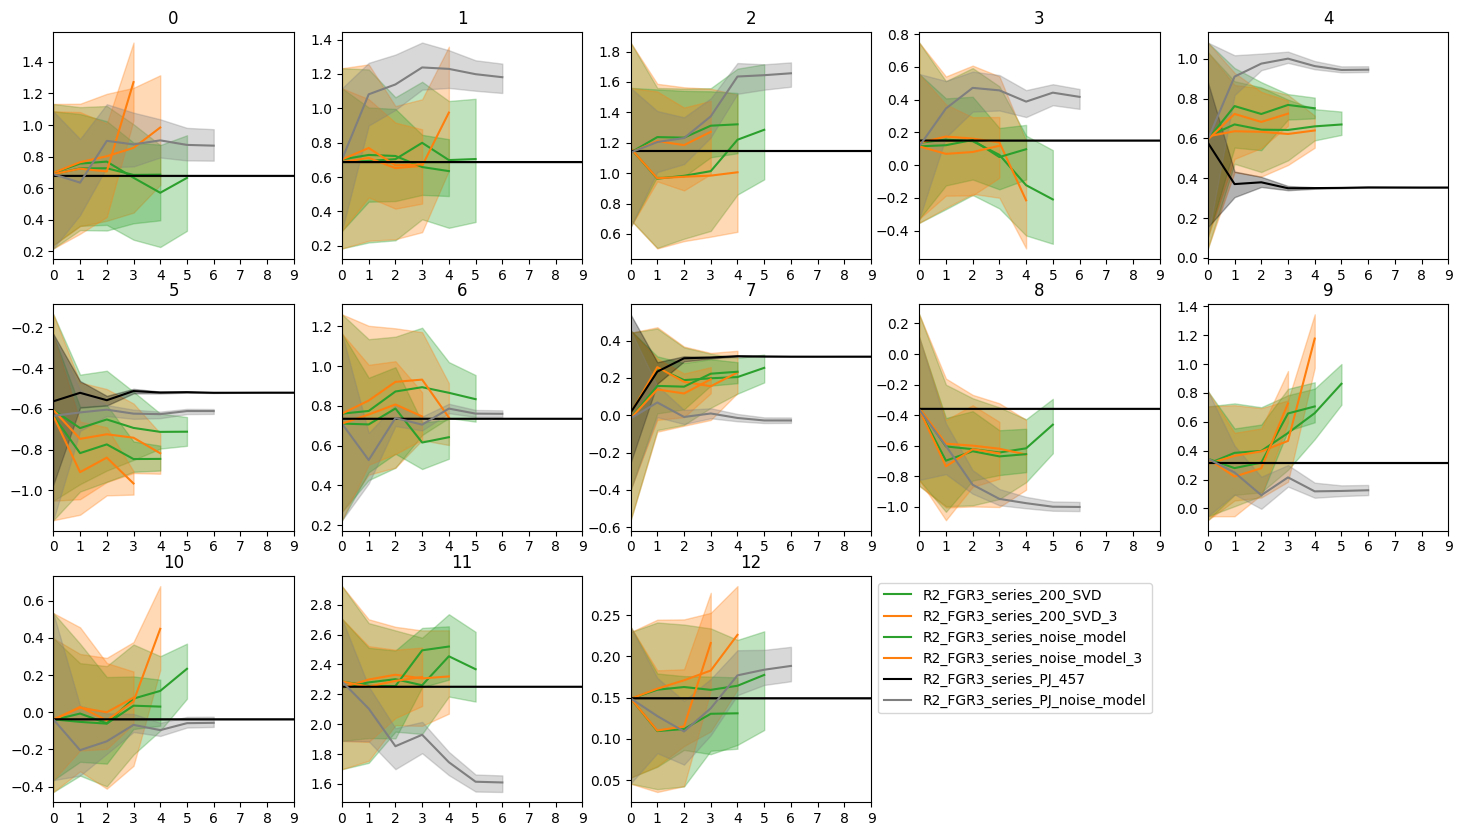

In [40]:
plt.figure(figsize=(18,10))
plot_params('R2_FGR3_series_200_SVD', color='tab:green')
plot_params('R2_FGR3_series_200_SVD_3', color='tab:orange')

plot_params('R2_FGR3_series_noise_model', color='tab:green')
plot_params('R2_FGR3_series_noise_model_3', color='tab:orange')

plot_params('R2_FGR3_series_PJ_457', color='k')

plot_params('R2_FGR3_series_PJ_noise_model', color='tab:gray')

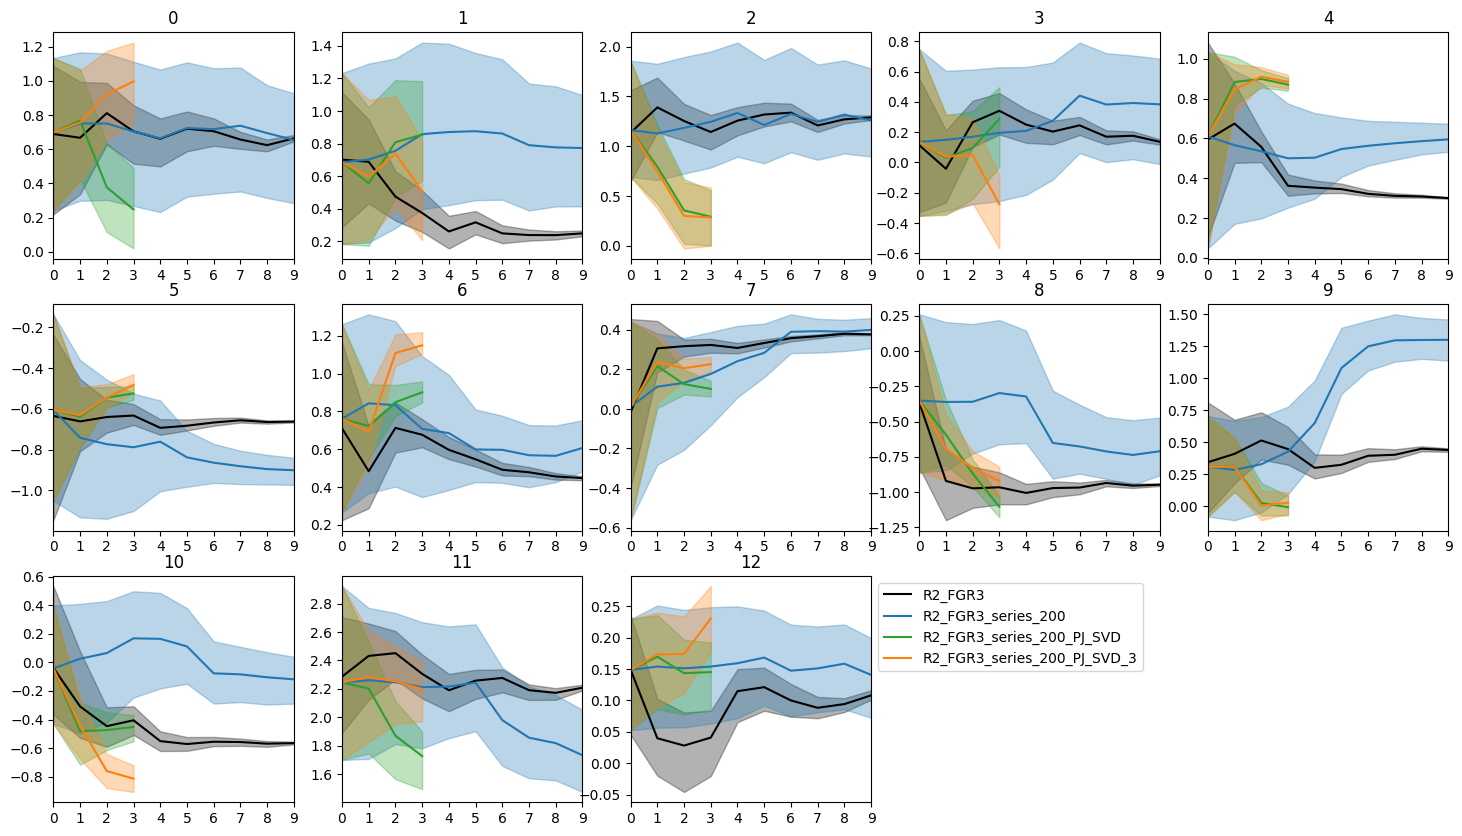

In [34]:
plt.figure(figsize=(18,10))
plot_params('R2_FGR3', color='k')
plot_params('R2_FGR3_series_200')
plot_params('R2_FGR3_series_200_PJ_SVD', color='tab:green')
plot_params('R2_FGR3_series_200_PJ_SVD_3', color='tab:orange')

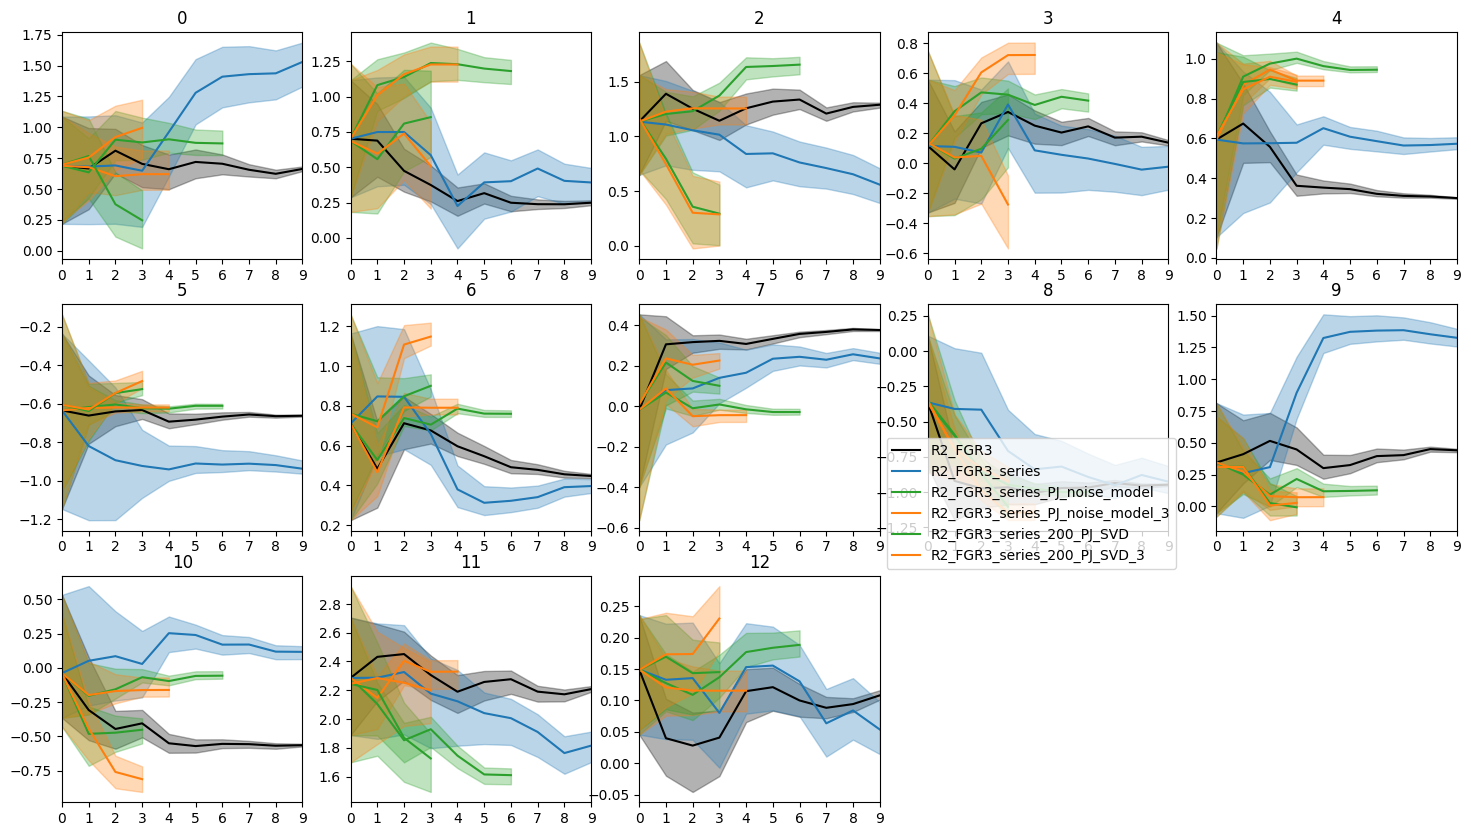

In [41]:
plt.figure(figsize=(18,10))
plot_params('R2_FGR3', color='k')
plot_params('R2_FGR3_series')
plot_params('R2_FGR3_series_PJ_noise_model', color='tab:green')
plot_params('R2_FGR3_series_PJ_noise_model_3', color='tab:orange')
plot_params('R2_FGR3_series_200_PJ_SVD', color='tab:green')
plot_params('R2_FGR3_series_200_PJ_SVD_3', color='tab:orange')

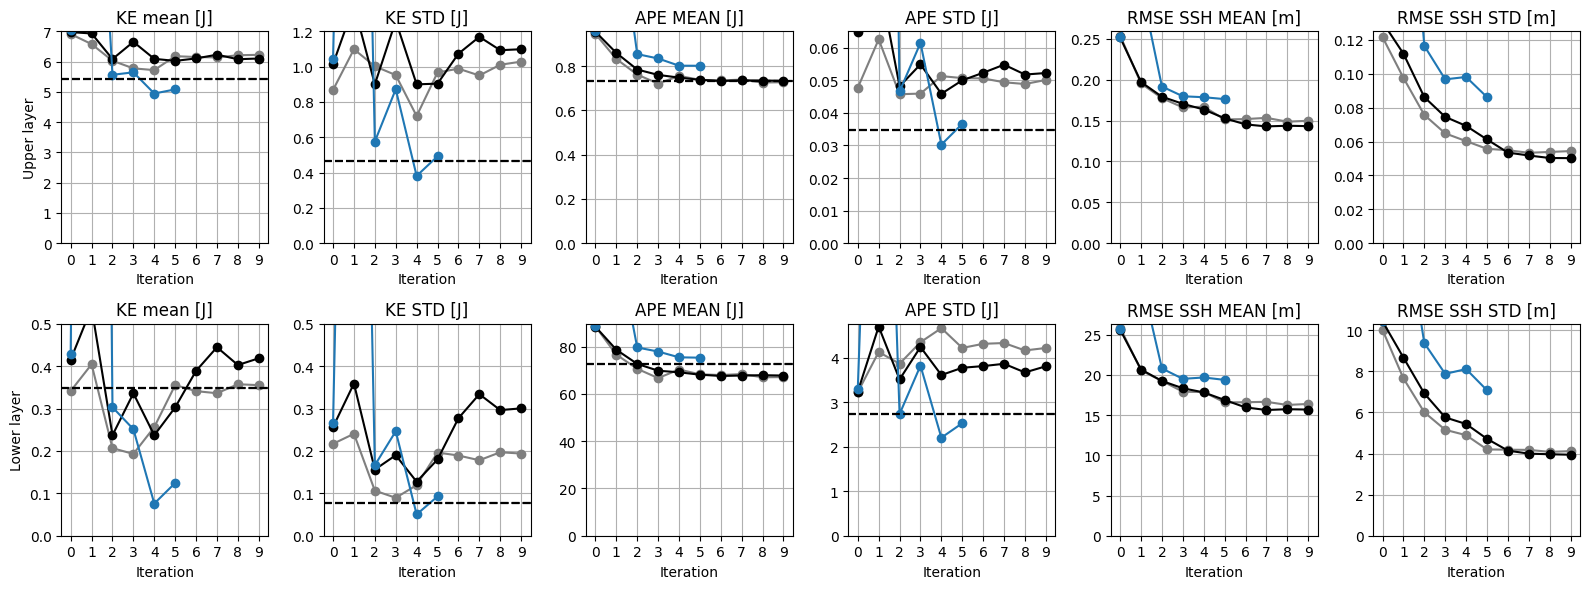

In [86]:
plt.figure(figsize=(16,6))
plot_metrics('R2_FGR3_series', color='tab:gray')
plot_metrics('R2_FGR3_series_200', color='k')
plot_metrics('R2_FGR3_series_200_SVD')
#plot_metrics('R2_FGR3_series_200_SVD_3', color='tab:orange')

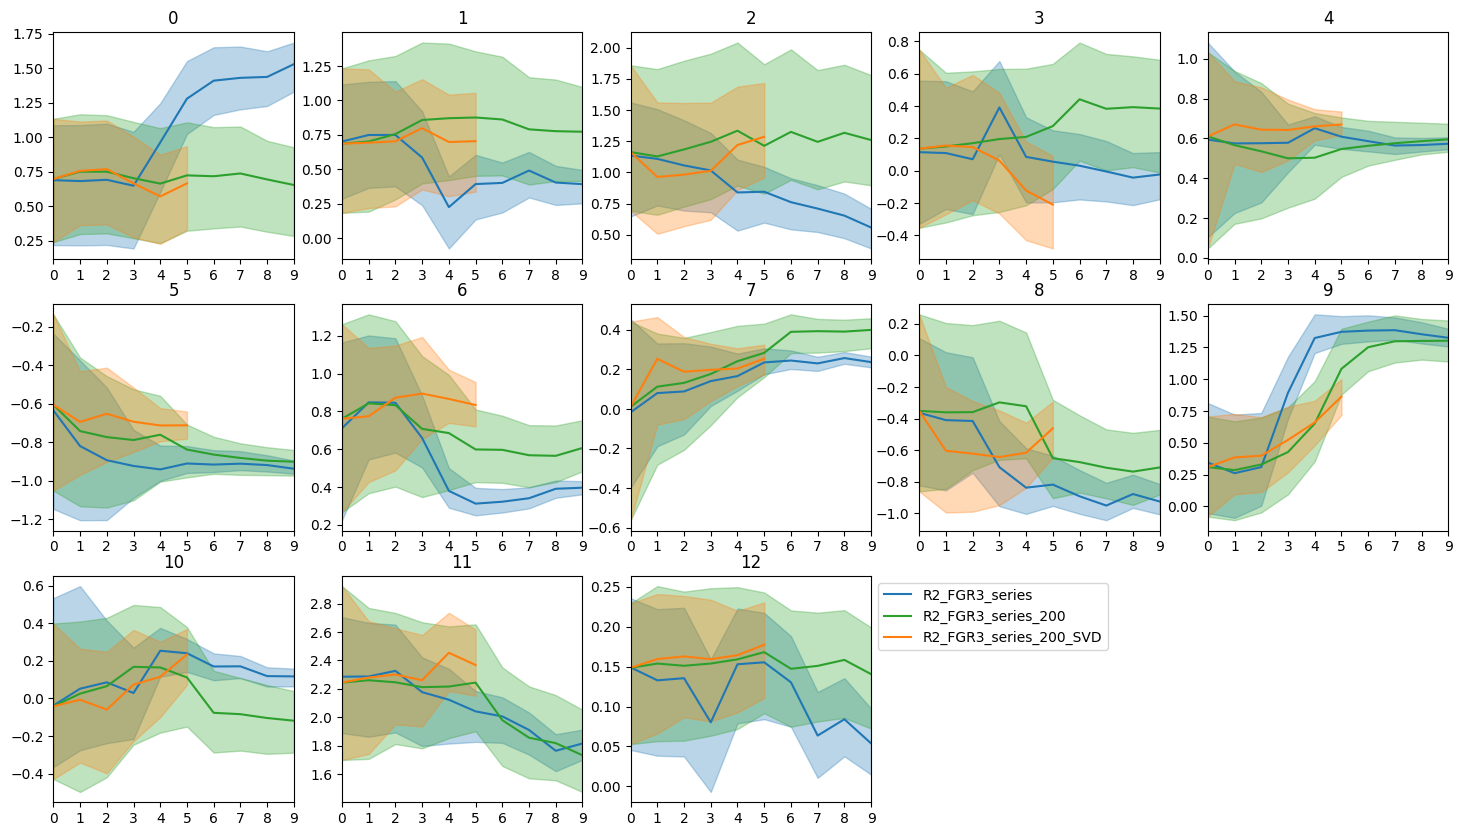

In [87]:
plt.figure(figsize=(18,10))
#plot_params('R2_FGR3', color='k')
plot_params('R2_FGR3_series')
plot_params('R2_FGR3_series_200', color='tab:green')
plot_params('R2_FGR3_series_200_SVD', color='tab:orange')

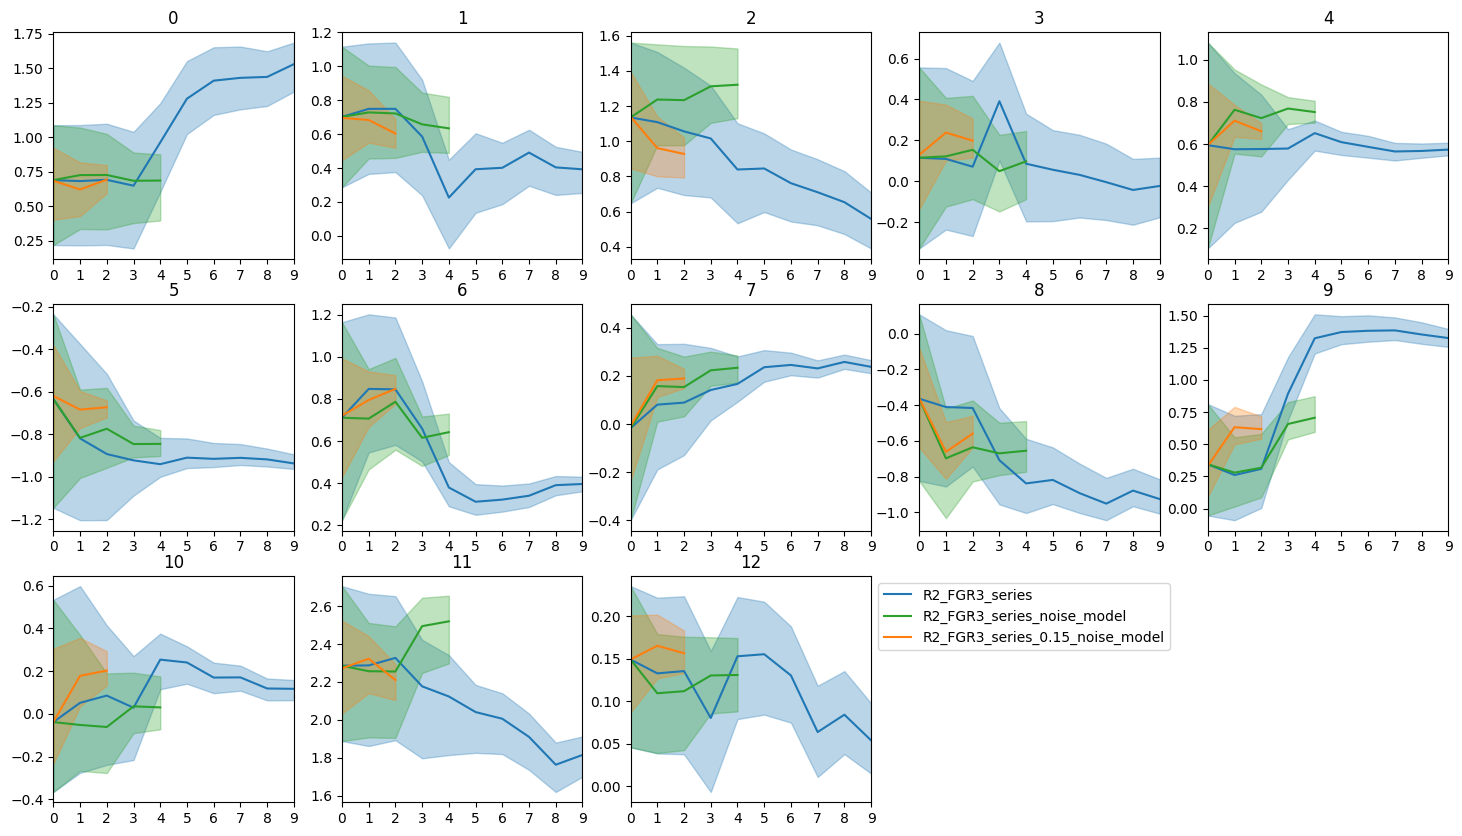

In [279]:
plt.figure(figsize=(18,10))
#plot_params('R2_FGR3', color='k')
plot_params('R2_FGR3_series')
plot_params('R2_FGR3_series_noise_model', color='tab:green')
plot_params('R2_FGR3_series_0.15_noise_model', color='tab:orange')

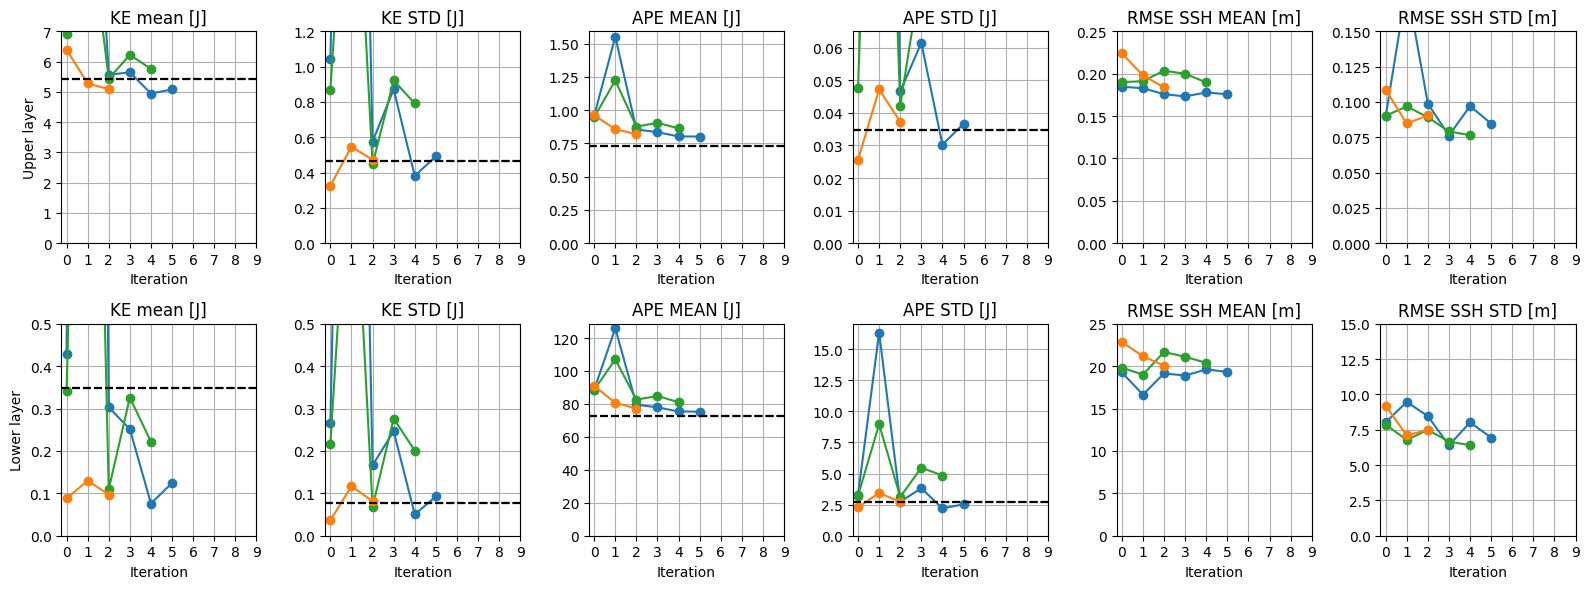

In [289]:
plt.figure(figsize=(16,6))
#plot_metrics('R2_FGR3_series', color='tab:gray')
plot_metrics('R2_FGR3_series_200_SVD', color='tab:blue')
plot_metrics('R2_FGR3_series_noise_model', color='tab:green')
plot_metrics('R2_FGR3_series_0.15_noise_model', color='tab:orange')

# Parameter selection
* Keep only those parameters which have the response twice the noise model level. Twice because this is our baseline noise model: noise + regularization.
* We keep using the old loss function because new one results in shrinking the ensemble but not improving any metrics!

# Trace of noise covariance matrix

In [22]:
noise_model = xr.open_dataset('/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/noise_model/metrics_00.nc').isel(iter=0).load()
observation_netcdf = xr.open_dataset('../scripts/R32/R2_FGR3_series_loss.nc').load()

observational_vector = ["e_mean", "e_std", "KE_mean", "KE_std", "APE_mean", "APE_std"]
gamma_vector = ["e_mean_var_loss", "e_std_var_loss", "KE_mean_var_loss", "KE_std_var_loss", "APE_mean_var_loss", "APE_std_var_loss"]

len_obs = np.sum([observation_netcdf[metric].size for metric in observational_vector])
ens_size = len(noise_model.ens)

# Create forward model evaluation matrix
g_ens = np.full(
    (len_obs, ens_size),
    np.nan,
    dtype="float64"
)

# We create observational matrix in normalized space where usual L2-norm returns answer in PetaJoules
for ens_member in range(ens_size):
    g_ens[:,ens_member] = np.concatenate([
        noise_model[metric].isel(ens=ens_member).values.ravel() / np.sqrt(observation_netcdf[gamma].values.ravel()) 
        for metric, gamma in zip(observational_vector, gamma_vector)])

In [24]:
# Find fluctuations
g_ens = g_ens - g_ens.mean(1,keepdims=True)

noise_trace = (np.sum(g_ens**2,0)).mean()
noise_trace

0.20535111650325952

# Initial ensemble

In [261]:
metrics = xr.open_mfdataset(f'/scratch/pp2681/mom6/CM26_Double_Gyre/calibration/20-years/R2_FGR3_series_0.15_noise_model/metrics*.nc').isel(iter=1)
valid_ens = ~metrics.KE_mean.isnull().any(dim=[d for d in metrics.KE_mean.dims if d != 'ens']).values

# Select only valid ensemble members
metrics = metrics.isel(ens=valid_ens)
ens_size = len(metrics.ens)

In [262]:
ens_size = len(metrics.ens)
# Create forward model evaluation matrix
g_ens = np.full(
    (len_obs, ens_size),
    np.nan,
    dtype="float64"
)


# We create observational matrix in normalized space where usual L2-norm returns answer in PetaJoules
for ens_member in range(ens_size):
    g_ens[:,ens_member] = np.concatenate([
        metrics[metric].isel(ens=ens_member).values.ravel() / np.sqrt(observation_netcdf[gamma].values.ravel()) 
        for metric, gamma in zip(observational_vector, gamma_vector)])

y_true = np.concatenate([
        observation_netcdf[metric].values.ravel() / np.sqrt(observation_netcdf[gamma].values.ravel()) 
        for metric, gamma in zip(observational_vector, gamma_vector)])

In [263]:
g_dash = g_ens - g_ens.mean(1,keepdims=True)
param_dash = (metrics.param - metrics.param.mean('ens')).values.T

In [264]:
C_xx = param_dash @ param_dash.T / (ens_size-1)
C_yx = g_dash @ param_dash.T / (ens_size-1)

In [265]:
import scipy
# Sensitivity matrix
S = C_yx @ np.linalg.inv(C_xx) * np.sqrt(np.diag(C_xx))
#S = C_yx @ np.linalg.inv(scipy.linalg.sqrtm(C_xx))
# Sensitivity per parameter
Sn = (S**2).sum(0)

In [266]:
ensemble_spread = np.sum(g_dash**2,0).mean()
ensemble_spread

1.7603703470860605

In [267]:
model_error = np.sum((g_ens.mean(1) - y_true)**2)
model_error

1.7326026167876756

## SSR (Spread skill ratio)

In [268]:
SSR = ensemble_spread / model_error
SSR

1.016026600692701

# SNR (Signal to noise ratio)

In [269]:
SNR = ensemble_spread / noise_trace
SNR

8.57248977780999

# SNR per parameter

(0.0, 151.0)

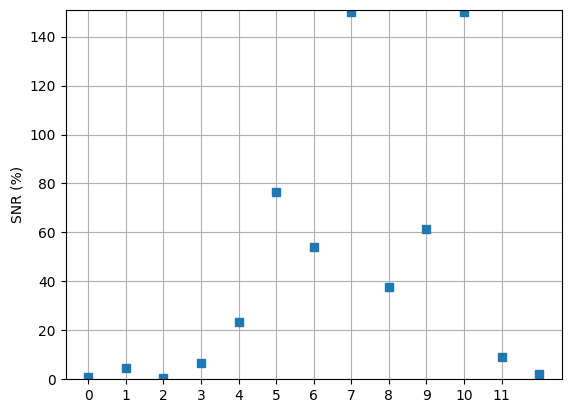

In [270]:
SNR_per_parameter = Sn / noise_trace
SNR_per_parameter * 100
plt.plot(np.minimum(SNR_per_parameter * 100, 150), marker='s', ls='')
plt.grid()
plt.ylabel('SNR (%)')
plt.xticks(np.arange(12));
plt.ylim([0, 151])

# Explained Variance (EV)

In [271]:
EV = Sn.sum() / ensemble_spread
EV * 100

100.98066181104888

In [272]:
Sn.sum()

1.7776336268129622

In [273]:
ensemble_spread

1.7603703470860605

# Explained Variance per parameter

In [274]:
EV_per_parameter = Sn / ensemble_spread
EV_per_parameter * 100

array([ 0.09890638,  0.51375832,  0.07985945,  0.77865708,  2.73210913,
        8.91613743,  6.3034219 , 43.98716584,  4.42158767,  7.16154546,
       24.69021405,  1.0481784 ,  0.24912071])

# Alignment of sensitivity vectors and model error

(0.0, 50.0)

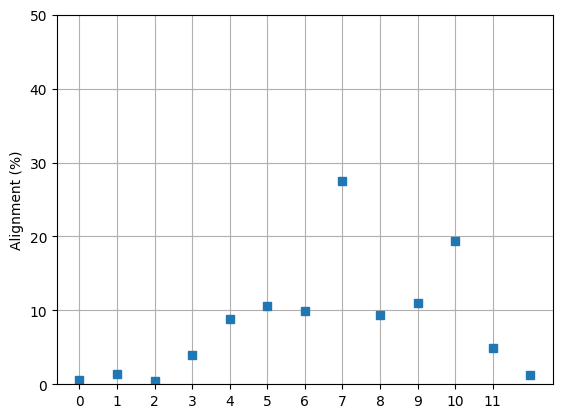

In [275]:
alignment = np.abs((S.T @ (g_ens.mean(1) - y_true))) / model_error

plt.plot(np.minimum(alignment * 100, 150), marker='s', ls='')
plt.grid()
plt.ylabel('Alignment (%)')
plt.xticks(np.arange(12));
plt.ylim([0, 50])